<a href="https://colab.research.google.com/github/adrianmisi/Est2_TareaAcademica/blob/main/BD_TareaAcademica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. Importación de Datos
url_covid <- 'https://raw.githubusercontent.com/adrianmisi/Est2_TareaAcademica/main/BD_TareaAcad%C3%A9mica%20-%20COVID19.csv'
url_elecciones <- 'https://raw.githubusercontent.com/adrianmisi/Est2_TareaAcademica/main/BD_TareaAcad%C3%A9mica%20-%20Elecciones%202021.csv'
url_energia <- 'https://raw.githubusercontent.com/adrianmisi/Est2_TareaAcademica/main/BD_TareaAcad%C3%A9mica%20-%20Energ%C3%ADa.csv'

bd_covid <- read.csv(url_covid, stringsAsFactors = FALSE, fileEncoding = 'UTF-8')
bd_elecciones <- read.csv(url_elecciones, stringsAsFactors = FALSE, fileEncoding = 'UTF-8')
bd_energia <- read.csv(url_energia, stringsAsFactors = FALSE, fileEncoding = 'UTF-8')

head(bd_covid)

,Departamento,Provincia,Total_Fallecidos_2020,Poblacion_2017
,<chr>,<chr>,<int>,<int>
1,AMAZONAS,BAGUA,270,74100
2,AMAZONAS,BONGARA,25,25637
3,AMAZONAS,CHACHAPOYAS,61,55506
4,AMAZONAS,CONDORCANQUI,79,42470
5,AMAZONAS,LUYA,20,44436
6,AMAZONAS,RODRIGUEZ DE MENDOZA,9,29998


In [2]:
# Uniendo covid y elecciones
df <- merge(bd_covid, bd_elecciones, by=c('Departamento', 'Provincia'))
# Uniendo con energía
df <- merge(df, bd_energia, by=c('Departamento', 'Provincia'))

head(df)

,Departamento,Provincia,Total_Fallecidos_2020,Poblacion_2017,Votos_Castillo,Votos_Keiko,No.usa.electricidad,Sí.usa.electricidad,No.usa.gas..balón.GLP.,Sí.usa.gas..balón.GLP.,⋯,No.usa.bosta,estiércol,Sí.usa.bosta,estiércol.1,No.usa.otros..residuos.agrícolas,etc..,Sí.usa.otros..residuos.agrícolas,etc...1,Sí.cocinan,No.cocinan
,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<lgl>,<lgl>,<lgl>,<lgl>
1,AMAZONAS,BAGUA,270,74100,25980,10770,20313,161,10557,9917,⋯,20474,0,20471,3,19776,698,NA,NA,NA,NA
2,AMAZONAS,BONGARA,25,25637,8374,5209,7689,124,3154,4659,⋯,7812,1,7813,0,7627,186,NA,NA,NA,NA
3,AMAZONAS,CHACHAPOYAS,61,55506,15671,10473,14763,574,4696,10641,⋯,15332,5,15334,3,14883,454,NA,NA,NA,NA
4,AMAZONAS,CONDORCANQUI,79,42470,14024,1446,9853,14,8331,1536,⋯,9867,0,9867,0,9769,98,NA,NA,NA,NA
5,AMAZONAS,LUYA,20,44436,12606,7840,13112,90,6863,6339,⋯,13197,5,13198,4,12955,247,NA,NA,NA,NA
6,AMAZONAS,UTCUBAMBA,130,107237,36540,19222,31248,255,15425,16078,⋯,31501,2,31480,23,30332,1171,NA,NA,NA,NA


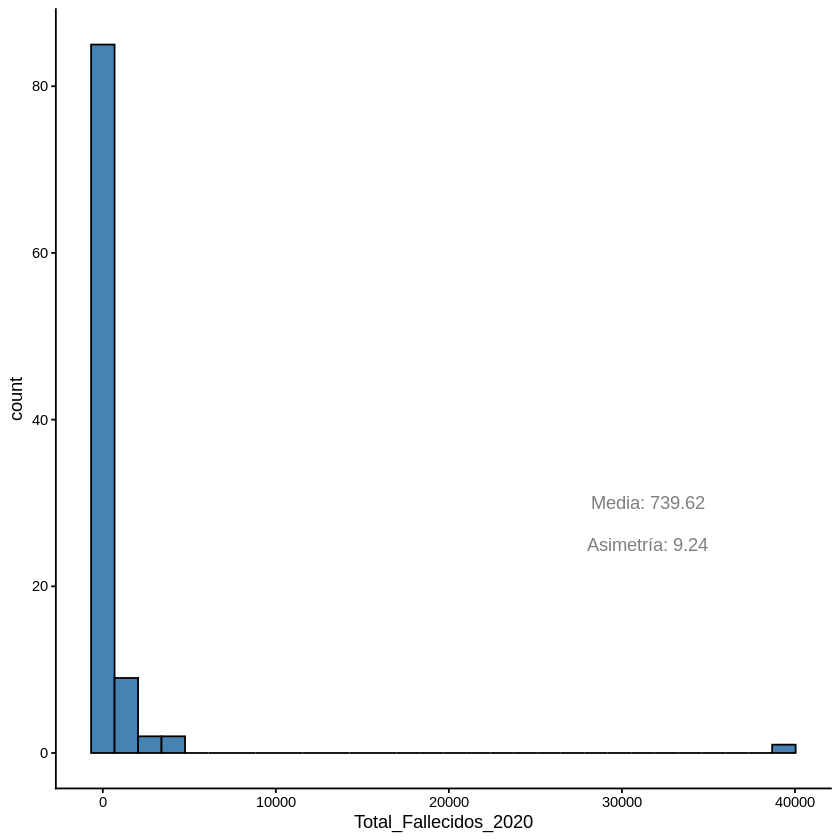

In [7]:
if (!requireNamespace("e1071", quietly = TRUE)) {
  install.packages("e1071")
}
library(ggplot2)
library(e1071)

VarDep <- df$Total_Fallecidos_2020
descris <- list(min=min(VarDep, na.rm=T),
                max=max(VarDep, na.rm=T),
                media=round(mean(VarDep, na.rm=T),2),
                var=round(var(VarDep, na.rm=T),2),
                asim=round(e1071::skewness(VarDep, na.rm=T),2),
                kurt=round(e1071::kurtosis(VarDep, na.rm=T),2))

base <- ggplot(data=df, aes(x=Total_Fallecidos_2020)) + theme_classic()
hist <- base + geom_histogram(bins=30, fill='steelblue', color='black')

histInfo <- hist +
  annotate('text', x = descris$max*0.8, y = 30, color='grey50', label = paste0('Media: ', descris$media)) +
  annotate('text', x = descris$max*0.8, y = 25, color='grey50', label = paste0('Asimetría: ', descris$asim))

histInfo

In [8]:
# Ejemplo: Efecto de los votos de un candidato sobre los fallecidos, usando la poblacion como offset
rp1 <- glm(Total_Fallecidos_2020 ~ Votos_Castillo + Votos_Keiko,
           data = df,
           offset = log(Poblacion_2017),
           family = poisson(link = 'log'))

summary(rp1)


Call:
glm(formula = Total_Fallecidos_2020 ~ Votos_Castillo + Votos_Keiko, 
    family = poisson(link = "log"), data = df, offset = log(Poblacion_2017))

Coefficients:
                 Estimate Std. Error  z value Pr(>|z|)    
(Intercept)    -5.924e+00  6.945e-03 -852.901  < 2e-16 ***
Votos_Castillo  4.449e-07  6.225e-08    7.148 8.83e-13 ***
Votos_Keiko    -8.503e-08  3.143e-08   -2.705  0.00683 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for poisson family taken to be 1)

    Null deviance: 14563.4  on 98  degrees of freedom
Residual deviance:  9863.7  on 96  degrees of freedom
AIC: 10508

Number of Fisher Scoring iterations: 5


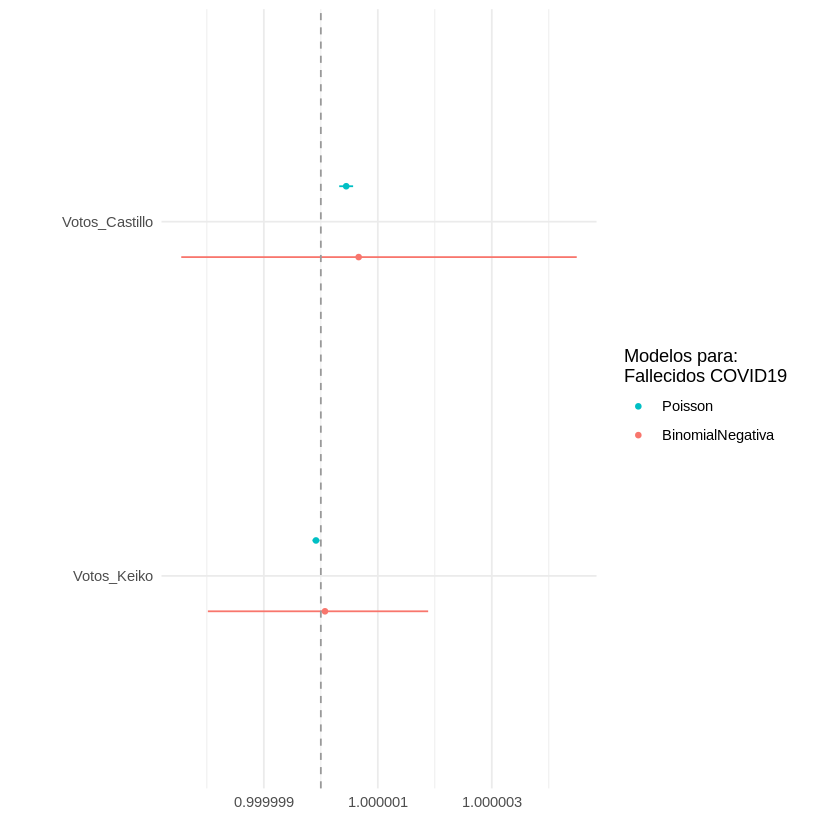

In [13]:
library(dotwhisker)
library(broom)

# Modelo alternativo Binomial Negativa
library(MASS)
rbn <- glm.nb(Total_Fallecidos_2020 ~ Votos_Castillo + Votos_Keiko + offset(log(Poblacion_2017)), data=df)

dotwhisker::dwplot(list(Poisson=rp1, BinomialNegativa=rbn), exp=T) +
  scale_color_discrete(name='Modelos para:\nFallecidos COVID19') +
  geom_vline(xintercept = 1, colour = 'grey60', linetype = 2) +
  theme_minimal()
